### 문제
- data 폴더 안에 bodyPerformance.csv 파일을 로드
- 데이터 중 object형 데이터의 컬럼들은 LabelEncoder를 이용하여 라벨링
- 독립, 종속 변수로 데이터를 나눠준다.
- train, test 데이터를 8:2의 비율로 나눠준다.
- 독립 데이터들은 StandardScaler를 이용하여 스케일링
- 생성된 변수 4개를 Tensor의 형태로 변환
- torch의 분류 분석을 통해서 데이터 학습
    - 손실함수는 Adam을 사용하고 lr의 값은 0.01로 설정
    - 반복 학습의 횟수는 200회 loss값 확인
- 반복 학습이 끝나면 정확도를 확인

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import pandas as pd

In [2]:
# 데이터 로드
df = pd.read_csv("../data/bodyPerformance.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB


In [7]:
# Object형 컬럼을 선택하여 LabelEncoder를 사용하여 라벨링
# Str형태의 데이터를 Int형태로 자동 변환

cols = df.select_dtypes('object').columns.tolist()

for col in cols:
    # LabelEncoder 생성
    le = LabelEncoder()
    # 각각 컬럼의 데이터들을 le에 학습하고 변환
    df[col] = le.fit_transform(df[col].values)

In [8]:
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1


In [9]:
# 해당 데이터를 이용하여 분류 분석 -> 정확도가 얼마나 되는가? -> 분류의 개수를 확인
# class 컬럼의 데이터들의 종류
df['class'].unique()

array([2, 0, 1, 3])

In [20]:
# 독립, 종속으로 데이터를 분할
X = df.drop('class', axis = 1).values
Y = df['class'].values
print(type(X), type(Y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [21]:
# train, test 데이터 분할
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [22]:
print(type(X_train), type(Y_train))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [23]:
# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
print(type(X_train), type(Y_train))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [25]:
# Tensor 타입으로 데이터를 타입 변경
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

In [26]:
# CrossEntropyLoss에서 사용할 데이터의 타입을 설정 -> long
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

In [83]:
# 모델 정의
class Bodycls(nn.Module):
    def __init__(self, _dim):
        # _dim : 입력 데이터의 피쳐의 개수를 받아오기 위한 매개변수
        super(Bodycls, self).__init__()
        # Sequential() -> 여러개의 층을 순서대로 실행
        self.model = nn.Sequential(
            nn.Linear(_dim, _dim * 3),    # 11차원의 입력데이터, 22차원의 출력데이터
            # 비선형 활성화 함수 (ReLU, Sigmoid, Tanh)
            nn.ReLU(),
            nn.Linear(_dim * 3, _dim * 2),
            nn.ReLU(),
            nn.Linear(_dim * 2, 4)
        )
        # self.model = nn.Linear(_dim, 4)
    
    def forward(self, x):
        return self.model(x)

In [84]:
# 모델을 생성
body_model = Bodycls(X_train.shape[1])

In [85]:
# 손실, 옵티마이저 생성
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(body_model.parameters(), lr= 0.01)

In [86]:
# 반복 학습
body_model.train()
for epoch in range(200):
    out = body_model(X_train_tensor)
    loss = criterion(out, Y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 40 == 0:
        print(f'Epoch : {epoch + 1}, Loss : {round(loss.item(), 4)}')

Epoch : 40, Loss : 0.8119
Epoch : 80, Loss : 0.6771
Epoch : 120, Loss : 0.6122
Epoch : 160, Loss : 0.5835
Epoch : 200, Loss : 0.5696


In [87]:
# 평가 모드 진입
body_model.eval()
with torch.no_grad():
    out = body_model(X_test_tensor)
    _, pred = torch.max(out, 1)   # 가장 높은 클래스를 선택
    acc = accuracy_score(Y_test, pred)

print(f'{round(acc * 100, 2)}%')

74.77%


In [88]:
# 비선형 활성화 함수 비교

import matplotlib.pyplot as plt

# sin 데이터를 하나 생성
x = torch.linspace(-3, 3, 200).unsqueeze(1)
y = torch.sin(x)

In [89]:
linear_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Linear(16, 1)
)

In [90]:
relu_model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

In [91]:
loss = nn.MSELoss()

opt1 = optim.Adam(linear_model.parameters(), lr = 0.01)
opt2 = optim.Adam(relu_model.parameters(), lr = 0.01)

In [92]:
# 반복 학습
for epoch in range(3000):
    # 선형 모델
    pred1 = linear_model(x)
    loss1 = loss(pred1, y)
    opt1.zero_grad()
    loss1.backward()
    opt1.step()

    # 비선형 모델
    pred2 = relu_model(x)
    loss2 = loss(pred2, y)
    opt2.zero_grad()
    loss2.backward()
    opt2.step()

In [93]:
# 예측 결과
linear_pred = linear_model(x).detach()
relu_pred = relu_model(x).detach()

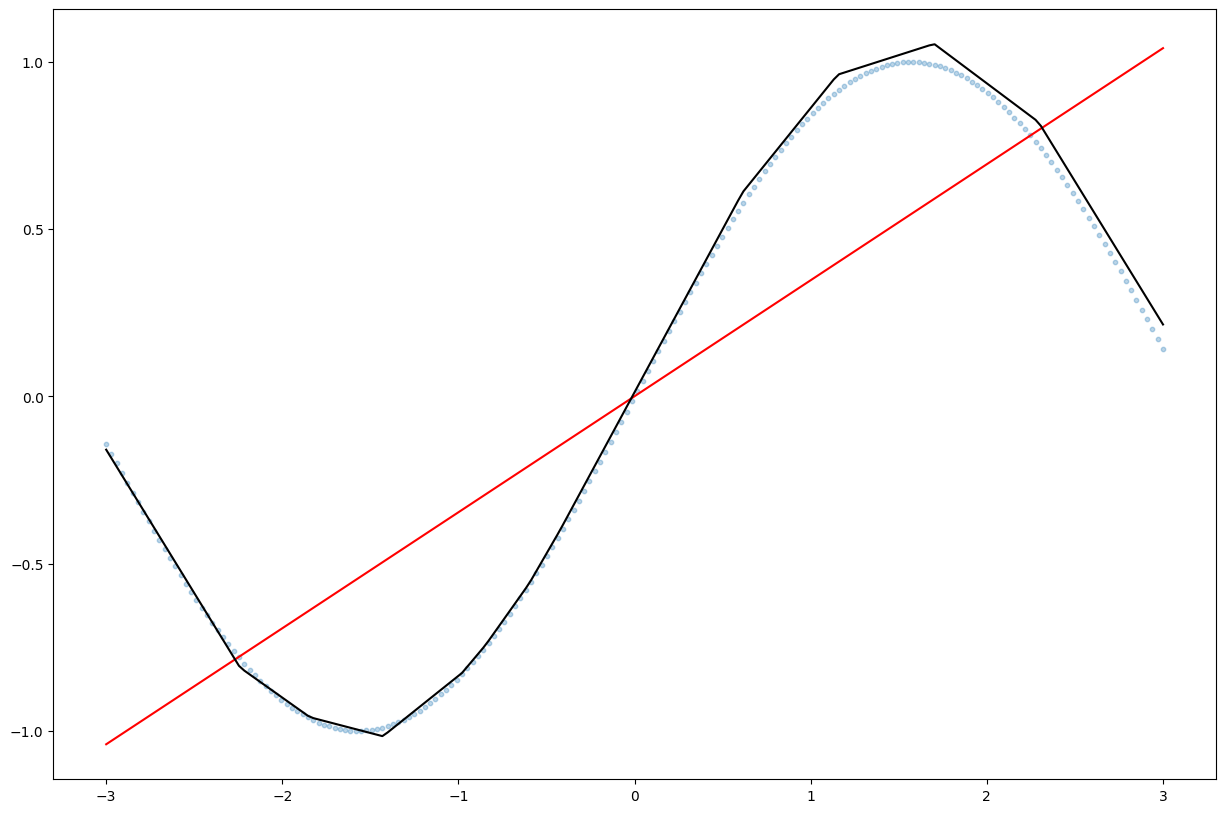

In [96]:
# 시각화
plt.figure(figsize = (15, 10))

# 원본 데이터 산점도 그래프
plt.scatter(x, y, s=10, alpha=0.3, label='Origin Data')
# 선형 모델 예측 값 -> 라인 그래프
plt.plot(x, linear_pred, color = 'red')
# 비선형 모델의 예측 값 -> 라인 그래프
plt.plot(x, relu_pred, color = 'black')